# Uygulamalı İstatistik Dersi 2025-2026

14 Kasım 2025 | 9. Hafta

Analiz Künyesi:
1. Amacı
2. Örneklem
3. Varsayım
4. Uygulama
5. Yorum

## Bağımsız Örneklem T Testi

Farklı isimlerle de anılır:

İki Örneklem T Testi\
Student T Testi\
Independent Samples T-Test\
Student's T-Test\
Two Sample T-Test

### Amaç

İki bağımsız grubun ortalamalarının birbirinden farklı olup olmadığını test etmek için kullanılır.

1. Kadınlar ve erkekler arasındaki boy ortalamaları arasında fark var mıdır?
2. Farklı 2 şubenin satış ortalamaları arasında fark var mıdır?

### Hipotezler

H0: XOrtalama1 **=** XOrtalama2\
H1: XOrtalama1 **!=** XOrtalama2\
H1: XOrtalama1 **>** XOrtalama2\
H1: XOrtalama1 **<** XOrtalama2

### Varsayımlar

1. Verilerin normalliği

   Her iki grubun da normal dağılması gerekir.

2. Varyans homojenliği

    Her iki grubun varyanslarının eşit olması gerekir.
    Standart sapmalar yaklaşık aynı olmalıdır.

Eğer bu varsayımlar sağlanmazsa, Mann-Whitney U testi kullanılabilir.

### Uygulama

#### Veri Seti

| -  | Deney | Kontrol |
|----|-------|---------|
| 1  | 9     | 15      |
| 2  | 13    | 11      |
| 3  | 11    | 13      |
| 4  | 7     | 8       |
| 5  | 9     | 17      |
| 6  | 8     | 8       |
| 7  | 16    | 15      |
| 8  | 9     | 10      |
| 9  | 15    | 12      |
| 10 | 12    | 13      |

In [6]:
# Veri girişi
deney <- c(9, 13, 11, 7, 9, 8, 16, 9, 15, 12)
cat("Deney grubunun sayısı:", length(deney), "\n")

kontrol <- c(15, 11, 13, 8, 17, 8, 15, 10, 12, 13)
cat("Kontrol grubunun sayısı:", length(kontrol), "\n")

if (length(deney) != length(kontrol)) {
  cat("Uyarı: Deney ve kontrol gruplarının sayıları eşit değil!\n")
}

ilac = c(deney, kontrol)

# Tekil kontroller
shapiro.test(deney)
shapiro.test(kontrol)

Deney grubunun sayısı: 10 
Kontrol grubunun sayısı: 10 



	Shapiro-Wilk normality test

data:  deney
W = 0.92824, p-value = 0.4308



	Shapiro-Wilk normality test

data:  kontrol
W = 0.95412, p-value = 0.7174


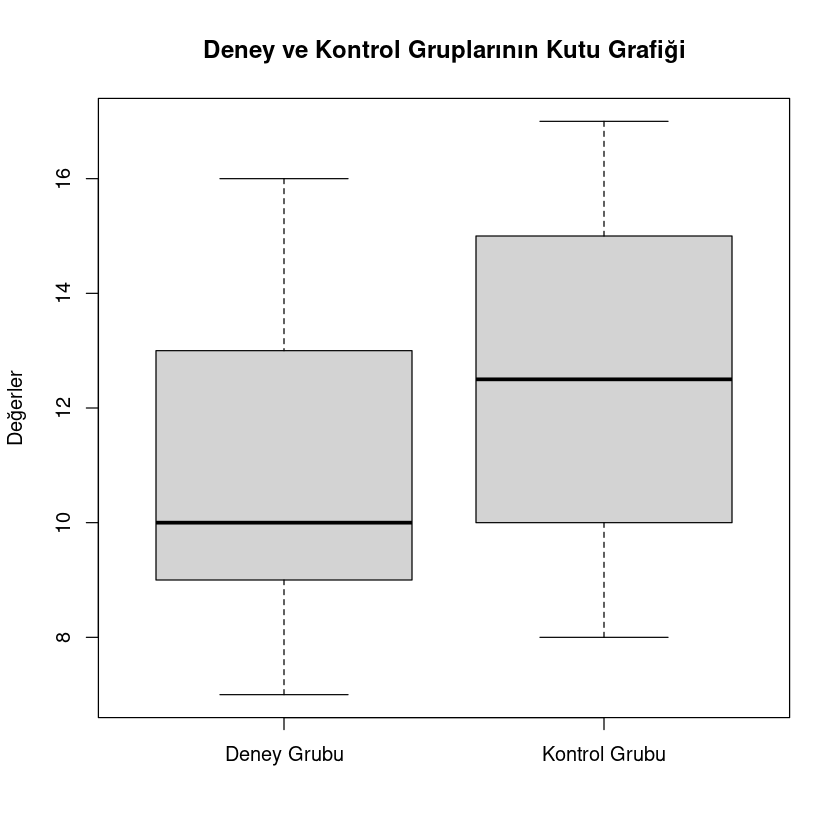

In [7]:
boxplot(deney, kontrol, names = c("Deney Grubu", "Kontrol Grubu"), main="Deney ve Kontrol Gruplarının Kutu Grafiği", ylab="Değerler")

In [8]:
shapiro.test(ilac) # Normallik testi
var.test(deney, kontrol) # Varyans homojenliği testi
# İki örneklem t testi
t.test(
    deney,
    kontrol,
    alt="less", # x_1 < x_2
    var.equal = TRUE # Varyansların eşit olduğu varsayımı. Varsanslar eşit çıkmazsa FALSE
) 


	Shapiro-Wilk normality test

data:  ilac
W = 0.94402, p-value = 0.2853



	F test to compare two variances

data:  deney and kontrol
F = 1.0159, num df = 9, denom df = 9, p-value = 0.9816
alternative hypothesis: true ratio of variances is not equal to 1
95 percent confidence interval:
 0.252343 4.090134
sample estimates:
ratio of variances 
          1.015931 



	Two Sample t-test

data:  deney and kontrol
t = -0.96157, df = 18, p-value = 0.1745
alternative hypothesis: true difference in means is less than 0
95 percent confidence interval:
     -Inf 1.044373
sample estimates:
mean of x mean of y 
     10.9      12.2 


### Yorum

H0: Deney ve kontrol gruplarının ortalamaları arasında fark yoktur.\
H1: Deney ve kontrol gruplarının ortalamaları arasında fark vardır.

**Test Çıktısı**:

```r
Two Sample t-test


data:  deney and kontrol
t = -0.96157, df = 18, p-value = 0.1745
alternative hypothesis: true difference in means is less than 0
95 percent confidence interval:
     -Inf 1.044373
sample estimates:
mean of x mean of y 
     10.9      12.2
```

p değeri 0.1745'tir. Bu değer 0.05'ten büyük olduğu için H0 hipotezi reddedilemez. Yani iki grup ortalamaları arasında anlamlı bir fark yoktur. Benzerlerdir.
Bu iki ortalama arasında istatistiksel olarak anlamlı bir fark yoktur.

### Uygulama 2

Gruplama değişkeni kullanılarak yapılışı:

In [9]:
grup <- c(
    "D", "D", "D", "D", "D", "D", "D", "D", "D", "D",
    "K", "K", "K", "K", "K", "K", "K", "K", "K", "K"
)

dk <- data.frame(ilac, grup)
dk

t.test(ilac~grup, alt="less", var.equal = TRUE)

ilac,grup
<dbl>,<chr>
9,D
13,D
11,D
7,D
9,D
8,D
16,D
9,D
15,D



	Two Sample t-test

data:  ilac by grup
t = -0.96157, df = 18, p-value = 0.1745
alternative hypothesis: true difference in means between group D and group K is less than 0
95 percent confidence interval:
     -Inf 1.044373
sample estimates:
mean in group D mean in group K 
           10.9            12.2 


### Yorum 2

H0: Deney ve kontrol gruplarının ortalamaları arasında fark yoktur.\
H1: Deney ve kontrol gruplarının ortalamaları arasında fark vardır.

**Test Çıktısı**:

```r
Two Sample t-test

data:  ilac by grup
t = -0.96157, df = 18, p-value = 0.1745
alternative hypothesis: true difference in means between group D and group K is less than 0
95 percent confidence interval:
     -Inf 1.044373
sample estimates:
mean in group D mean in group K 
           10.9            12.2
```

Deney ve kontrol grubunun ortalamaları bağımsız örneklem t testi ile karşılaştırılmadan önce normallik analizi uygulanmış ve verilerin normal dağıldığı görülmüştür.(p>0.05). Varyansların homojenliği incelenmiş ve homojen olduğu görülmüştür(p>0.05). Ortalamalar arasında istatistiksel olarak anlamlı bir fark elde edilememiştir.